# CS224N L01 Code Capsule: 余弦相似度与词类比算术

**Waypoint**: WP06 — 词向量评估：可视化、类比与偏差

**概念**: 余弦相似度 (cosine similarity) 与词类比算术 (word analogy)

**官方锚点**: A1 Part 2 Q2.2-2.6 (cosine similarity, analogy)

---

## 为什么需要跑代码？

A1 Q2.2-2.6 要求用 cosine similarity 做词类比，但 slides/notes 没有教：
1. cosine similarity 的计算公式和直觉
2. 向量算术 `king - man + woman ≈ queen` 为什么能工作
3. 类比什么时候会失败

只有实际跑才能理解这些。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def cosine_similarity(u, v):
    """计算两个向量的余弦相似度: cos(θ) = u·v / (||u|| * ||v||)"""
    dot = np.dot(u, v)
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0.0
    return dot / (norm_u * norm_v)

## Part 1: 构造 Toy 词向量

我们用 4 维向量，每个维度代表一个语义特征：
- **Dimension 0**: royalty（皇室）
- **Dimension 1**: maleness（男性）
- **Dimension 2**: femaleness（女性）
- **Dimension 3**: youth（年轻）

设计原则：语义特征正交分离，这样类比算术才能成立。

In [2]:
vocab = {
    "king":     np.array([0.95, 0.85, 0.05, 0.10]),
    "queen":    np.array([0.95, 0.08, 0.88, 0.12]),
    "man":      np.array([0.08, 0.88, 0.05, 0.50]),
    "woman":    np.array([0.05, 0.05, 0.90, 0.48]),
    "boy":      np.array([0.05, 0.88, 0.05, 0.95]),
    "girl":     np.array([0.05, 0.05, 0.90, 0.95]),
    "prince":   np.array([0.85, 0.82, 0.08, 0.90]),
    "princess": np.array([0.85, 0.08, 0.82, 0.90]),
    "dog":      np.array([0.00, 0.40, 0.00, 0.60]),
    "cat":      np.array([0.00, 0.00, 0.40, 0.60]),
}

print("Toy 词向量 (4维):")
print("维度含义: [royalty, maleness, femaleness, youth]")
for word, vec in vocab.items():
    print(f"  {word:10s} = [{vec[0]:.2f}, {vec[1]:.2f}, {vec[2]:.2f}, {vec[3]:.2f}]")

Toy 词向量 (4维):
维度含义: [royalty, maleness, femaleness, youth]
  king       = [0.95, 0.85, 0.05, 0.10]
  queen      = [0.95, 0.08, 0.88, 0.12]
  man        = [0.08, 0.88, 0.05, 0.50]
  woman      = [0.05, 0.05, 0.90, 0.48]
  boy        = [0.05, 0.88, 0.05, 0.95]
  girl       = [0.05, 0.05, 0.90, 0.95]
  prince     = [0.85, 0.82, 0.08, 0.90]
  princess   = [0.85, 0.08, 0.82, 0.90]
  dog        = [0.00, 0.40, 0.00, 0.60]
  cat        = [0.00, 0.00, 0.40, 0.60]


## Part 2: 计算余弦相似度

余弦相似度衡量两个向量的方向相似程度：
- `cos = 1.0`：完全相同方向（语义完全一致）
- `cos = 0.0`：正交（语义无关）
- `cos = -1.0`：完全相反方向

注意：我们比较的是**方向**而不是大小，所以用余弦而不是欧氏距离。

In [3]:
pairs = [
    ("king", "queen"),
    ("king", "man"),
    ("king", "woman"),
    ("man", "woman"),
    ("king", "dog"),
    ("dog", "cat"),
    ("boy", "girl"),
    ("prince", "princess"),
]

print("--- 词对余弦相似度 ---")
for w1, w2 in pairs:
    sim = cosine_similarity(vocab[w1], vocab[w2])
    print(f"  cos({w1:10s}, {w2:10s}) = {sim:.4f}")

print("\n[解读]")
print("  king-queen 高相似度 → 共享 'royalty' 维度")
print("  man-woman 中等相似度 → 共享 'age' 维度但性别相反")
print("  king-dog 低相似度 → 语义距离远")

--- 词对余弦相似度 ---
  cos(king      , queen     ) = 0.6157
  cos(king      , man       ) = 0.6738
  cos(king      , woman     ) = 0.1399
  cos(man       , woman     ) = 0.3204
  cos(king      , dog       ) = 0.4335
  cos(dog       , cat       ) = 0.6923
  cos(boy       , girl      ) = 0.5848
  cos(prince    , princess  ) = 0.7524

[解读]
  king-queen 高相似度 → 共享 'royalty' 维度
  man-woman 中等相似度 → 共享 'age' 维度但性别相反
  king-dog 低相似度 → 语义距离远


## Part 3: 词类比算术 (Word Analogy)

经典问题：`king - man + woman = ?`

**直觉**：
- `king - man` = 去掉"男性"成分，保留"皇室"成分
- `+ woman` = 加上"女性"成分
- 结果 = "皇室" + "女性" ≈ `queen`

**公式**：`result = a - b + c`，然后在词表中找与 result 余弦相似度最高的词。

In [4]:
def word_analogy(a, b, c, vocab_dict):
    """
    类比: a 之于 b 如同 c 之于 ?
    即: ? = a - b + c
    """
    result_vec = vocab_dict[a] - vocab_dict[b] + vocab_dict[c]
    
    similarities = []
    for word, vec in vocab_dict.items():
        if word in [a, b, c]:
            continue
        sim = cosine_similarity(result_vec, vec)
        similarities.append((word, sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return result_vec, similarities

# 经典类比
print("--- 经典类比: king - man + woman = ? ---")
result_vec, ranked = word_analogy("king", "man", "woman", vocab)
print(f"结果向量: [{result_vec[0]:.2f}, {result_vec[1]:.2f}, {result_vec[2]:.2f}, {result_vec[3]:.2f}]")
print(f"\n最接近的词:")
for rank, (word, sim) in enumerate(ranked, 1):
    marker = " ← 正确答案!" if word == "queen" else ""
    print(f"  #{rank}: {word:10s}  cos_sim = {sim:.4f}{marker}")

--- 经典类比: king - man + woman = ? ---
结果向量: [0.92, 0.02, 0.90, 0.08]

最接近的词:
  #1: queen       cos_sim = 0.9981 ← 正确答案!
  #2: princess    cos_sim = 0.8310
  #3: girl        cos_sim = 0.5520
  #4: prince      cos_sim = 0.4914
  #5: cat         cos_sim = 0.4387
  #6: boy         cos_sim = 0.1104
  #7: dog         cos_sim = 0.0602


In [5]:
analogies = [
    ("king", "man", "woman", "queen"),
    ("prince", "man", "woman", "princess"),
    ("king", "queen", "man", "boy"),
    ("king", "queen", "prince", "man"),
    ("boy", "girl", "man", "dog"),
    ("prince", "princess", "king", "man"),
]

print("--- 更多类比测试 ---")
for a, b, c, expected in analogies:
    result_vec, ranked = word_analogy(a, b, c, vocab)
    top_word, top_sim = ranked[0]
    correct = top_word == expected
    status = "✓" if correct else "✗"
    print(f"  {status} {a} - {b} + {c} = {top_word} (expected: {expected}, sim={top_sim:.4f})")

--- 更多类比测试 ---
  ✓ king - man + woman = queen (expected: queen, sim=0.9981)
  ✓ prince - man + woman = princess (expected: princess, sim=0.9955)
  ✓ king - queen + man = boy (expected: boy, sim=0.7646)
  ✓ king - queen + prince = man (expected: man, sim=0.8588)
  ✓ boy - girl + man = dog (expected: dog, sim=0.6981)
  ✓ prince - princess + king = man (expected: man, sim=0.7410)


## Part 4: 类比失败案例

类比不是万能的。以下情况会失败：
1. **跨语义域**：动物域的关系不能直接迁移到皇室域
2. **无清晰关系**：当 a→b 没有明确语义关系时，类比结果无意义
3. **维度干扰**：toy 向量中多个语义特征混合时，差向量不纯净

In [6]:
print("--- 失败案例 1: 跨语义域 ---")
result_vec, ranked = word_analogy("dog", "cat", "king", vocab)
print(f"dog - cat + king = ?")
print(f"Top-3: {ranked[:3]}")
print(f"[解读] dog→cat 的关系不能干净地迁移到 king 上\n")

print("--- 失败案例 2: 无对应关系 ---")
result_vec, ranked = word_analogy("dog", "king", "man", vocab)
print(f"dog - king + man = ?")
print(f"Top-3: {ranked[:3]}")
print(f"[解读] dog→king 没有清晰语义关系，结果无意义")

--- 失败案例 1: 跨语义域 ---
dog - cat + king = ?
Top-3: [('prince', np.float64(0.7904838446161117)), ('man', np.float64(0.7376590279066687)), ('boy', np.float64(0.586081786712776))]
[解读] dog→cat 的关系不能干净地迁移到 king 上

--- 失败案例 2: 无对应关系 ---
dog - king + man = ?
Top-3: [('boy', np.float64(0.7109957348187936)), ('cat', np.float64(0.597100356104323)), ('girl', np.float64(0.5081563476808868))]
[解读] dog→king 没有清晰语义关系，结果无意义


## Part 5: 可视化

### 5.1 余弦相似度热力图

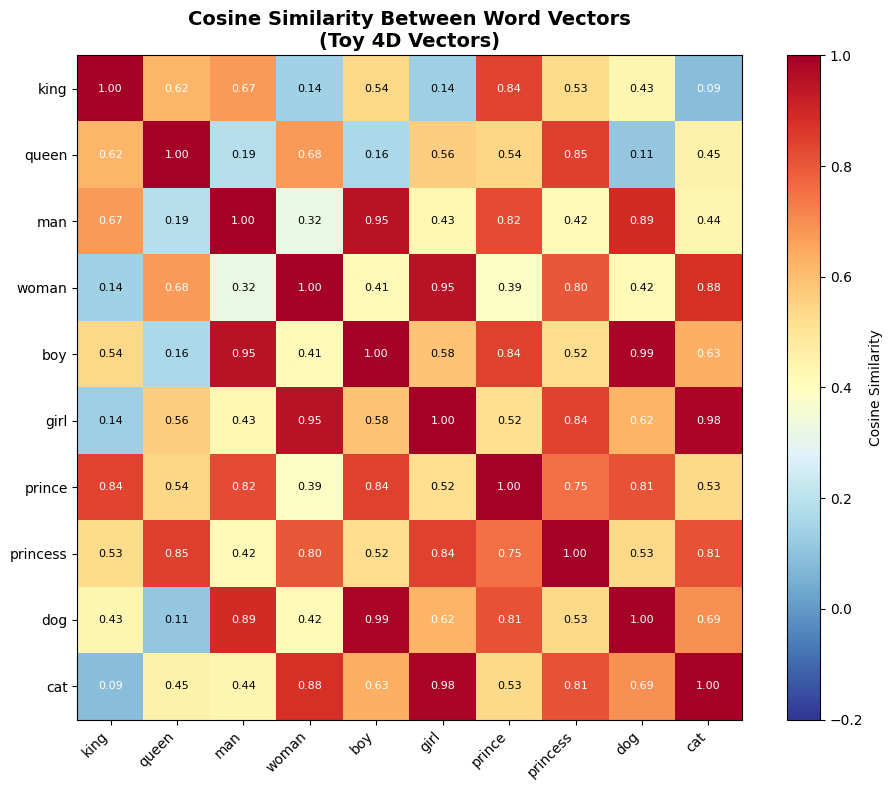

In [7]:
words = list(vocab.keys())
n = len(words)
sim_matrix = np.zeros((n, n))
for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        sim_matrix[i, j] = cosine_similarity(vocab[w1], vocab[w2])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(words, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(words, fontsize=10)

for i in range(n):
    for j in range(n):
        val = sim_matrix[i, j]
        color = "white" if val > 0.6 or val < 0.1 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)

plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_title('Cosine Similarity Between Word Vectors\n(Toy 4D Vectors)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 2D 投影与类比箭头

平行箭头展示类比关系：`man→king` 和 `woman→queen` 应该平行（都加上 royalty）。

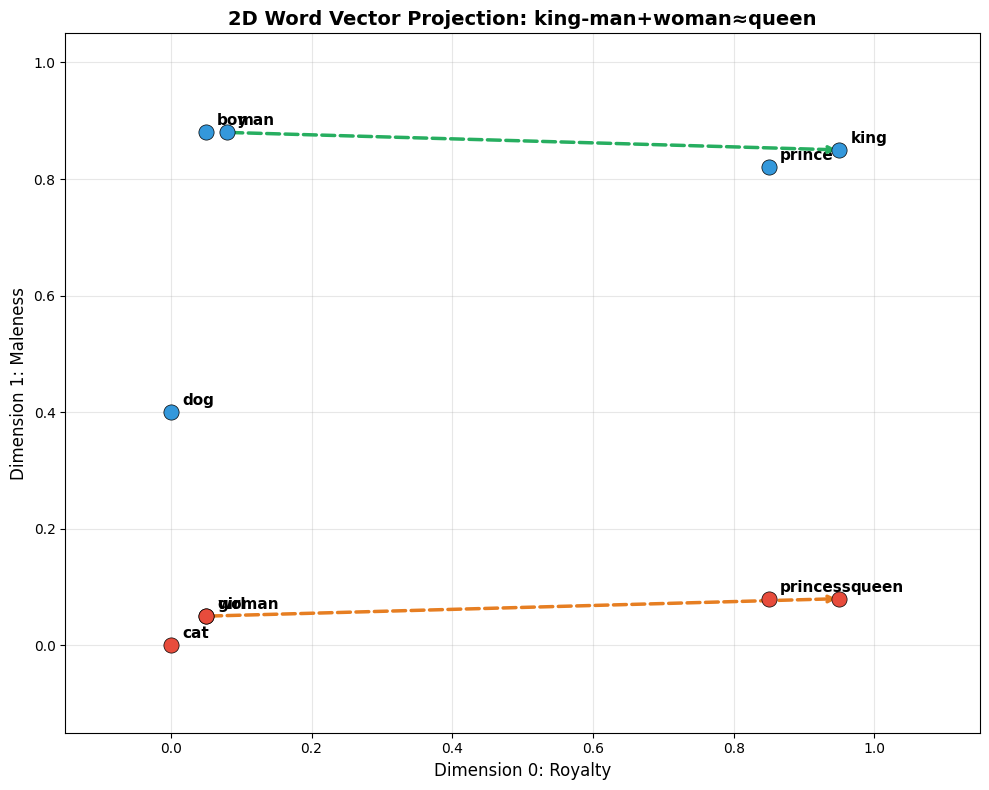

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

plot_words = ["king", "queen", "man", "woman", "boy", "girl", "prince", "princess", "dog", "cat"]
for word in plot_words:
    vec = vocab[word]
    color = '#3498db' if vec[1] > vec[2] else ('#e74c3c' if vec[2] > vec[1] else '#95a5a6')
    ax.scatter(vec[0], vec[1], s=120, zorder=5, color=color, edgecolors='black', linewidth=0.5)
    ax.annotate(word, (vec[0], vec[1]), textcoords="offset points", xytext=(8, 5), fontsize=11, fontweight='bold')

# Analogy arrows
ax.annotate('', xy=(vocab["king"][0], vocab["king"][1]), xytext=(vocab["man"][0], vocab["man"][1]),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2.5, linestyle='--'))
ax.annotate('', xy=(vocab["queen"][0], vocab["queen"][1]), xytext=(vocab["woman"][0], vocab["woman"][1]),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2.5, linestyle='--'))

ax.set_xlabel('Dimension 0: Royalty', fontsize=12)
ax.set_ylabel('Dimension 1: Maleness', fontsize=12)
ax.set_title('2D Word Vector Projection: king-man+woman≈queen', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.05)
plt.tight_layout()
plt.show()

## 总结

1. **余弦相似度**衡量词向量方向相似程度，适合比较高维稀疏向量
2. **词类比算术** `a - b + c ≈ d` 在语义特征正交分离时工作良好
3. **失败模式**：跨语义域、无清晰关系、维度干扰
4. **真实 word2vec**：300维向量中，类比准确率约 40-60%（取决于词表和训练数据）

---

**对应 A1 作业**: Part 2 Q2.2-2.6 要求你实现 cosine similarity 和 analogy 测试。

**下一步**: 在 A1 中用 GloVe 预训练向量做同样的实验，观察真实向量的表现。